<a href="https://colab.research.google.com/github/abhishekanand04/ML-Unsupervised-and-RecSys/blob/unsupervised/Rec_Sys_MF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
ratings = pd.read_csv(
    "https://files.grouplens.org/datasets/movielens/ml-100k/u.data",
    sep="\t",
    names=["user", "item", "rating", "timestamp"]
)

ratings.head()

,user,item,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
user_ids = ratings.user.unique()
item_ids = ratings.item.unique()

In [ ]:
len(item_ids)

1682

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

In [ ]:
def predict(u,i):
  return mu + bu[u] + bi[i] + np.dot(P[u], Q[i])

In [ ]:
d = 20

In [ ]:
ratings

,user,item,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [ ]:
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {i: j for j, i in enumerate(item_ids)}

In [ ]:
ratings["user_idx"] = ratings.user.map(user2idx)
ratings["item_idx"] = ratings.item.map(item2idx)

In [ ]:
ratings

,user,item,rating,timestamp,user_idx,item_idx
0,196,242,3,881250949,0,0
1,186,302,3,891717742,1,1
2,22,377,1,878887116,2,2
3,244,51,2,880606923,3,3
4,166,346,1,886397596,4,4
...,...,...,...,...,...,...
99995,880,476,3,880175444,875,173
99996,716,204,5,879795543,708,247
99997,276,1090,1,874795795,37,1004
99998,13,225,2,882399156,58,443


In [ ]:
n_users = ratings.user_idx.nunique()
n_items = ratings.item_idx.nunique()

In [ ]:
P = np.random.normal(0, 0.1, (n_users, d))  # user vectors
Q = np.random.normal(0, 0.1, (n_items, d))  # item vectors

In [ ]:
bu = np.zeros(n_users)  # user bias
bi = np.zeros(n_items)

In [ ]:
def rmse(data):
    errors = []
    for _, row in data.iterrows():
        pred = predict(row.user_idx, row.item_idx)
        errors.append((row.rating - pred) ** 2)
    return np.sqrt(np.mean(errors))

## Training part of MF

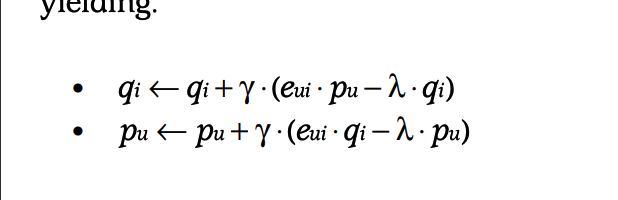

In [ ]:
epochs = 10

In [ ]:
train

,user,item,rating,timestamp,user_idx,item_idx
75220,807,1411,1,893082619,804,901
48955,474,659,5,887925187,467,488
44966,463,268,4,877384940,465,139
13568,139,286,4,879537844,321,289
92727,621,751,4,883799651,618,261
...,...,...,...,...,...,...
6265,216,231,2,880245109,81,146
54886,343,276,5,876403078,339,695
76820,437,475,3,880140288,434,355
860,284,322,3,885329671,40,51


In [ ]:
mu = train.rating.mean()

In [ ]:
mu

np.float64(3.5312625)

In [ ]:
lr = 0.03

In [ ]:
lambda_reg = 0.1

In [ ]:
for epoch in range(epochs):
    for _, row in train.iterrows():
        u = row.user_idx
        i = row.item_idx
        r = row.rating

        err = r - predict(u, i)

        # Update biases
        bu[u] += lr * (err - lambda_reg * bu[u])
        bi[i] += lr * (err - lambda_reg * bi[i])

        # Save old vectors
        Pu = P[u].copy()
        Qi = Q[i].copy()

        # Update latent vectors
        P[u] += lr * (err * Qi - lambda_reg * Pu)
        Q[i] += lr * (err * Pu - lambda_reg * Qi)

    print(f"Epoch {epoch+1}, Train RMSE: {rmse(train):.4f}, Test RMSE: {rmse(test):.4f}")

Epoch 1, Train RMSE: 0.9363, Test RMSE: 0.9568
Epoch 2, Train RMSE: 0.9229, Test RMSE: 0.9491
Epoch 3, Train RMSE: 0.9161, Test RMSE: 0.9463
Epoch 4, Train RMSE: 0.9091, Test RMSE: 0.9436
Epoch 5, Train RMSE: 0.8995, Test RMSE: 0.9397
Epoch 6, Train RMSE: 0.8881, Test RMSE: 0.9353
Epoch 7, Train RMSE: 0.8768, Test RMSE: 0.9316
Epoch 8, Train RMSE: 0.8659, Test RMSE: 0.9287
Epoch 9, Train RMSE: 0.8549, Test RMSE: 0.9263
Epoch 10, Train RMSE: 0.8434, Test RMSE: 0.9242


In [ ]:
def recommend_movies(user_id, top_k=5):
    u = user2idx[user_id]
    scores = []

    for item_id in item_ids:
        i = item2idx[item_id]
        scores.append((item_id, predict(u, i)))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

In [ ]:
recommend_movies(user_id = 1)

[(np.int64(169), np.float64(4.888175516121688)),
 (np.int64(474), np.float64(4.831485504231089)),
 (np.int64(127), np.float64(4.817030276750311)),
 (np.int64(56), np.float64(4.802341860005386)),
 (np.int64(408), np.float64(4.800806344648902))]

In [ ]:
P.shape

(943, 20)

In [ ]:
Q.shape

(1682, 20)

## TSNE

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [ ]:
user_emb_2d = TSNE(n_components=2, perplexity=50).fit_transform(P)

In [ ]:
user_emb_2d.shape

(943, 2)

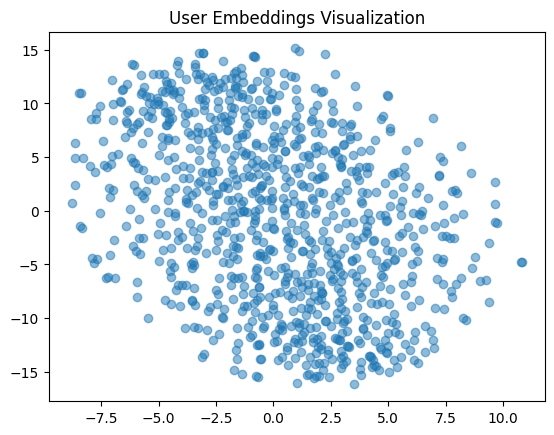

In [ ]:
plt.scatter(user_emb_2d[:,0], user_emb_2d[:,1], alpha = 0.5)
plt.title("User Embeddings Visualization")
plt.show()

## Optional - Eigen Faces

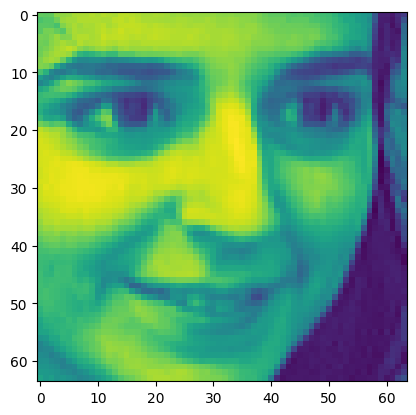

In [ ]:
plt.imshow(images[4])

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


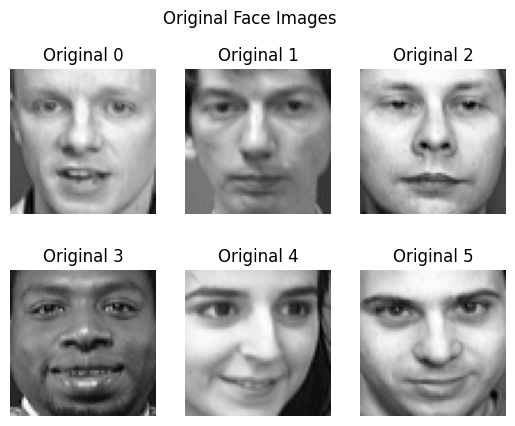

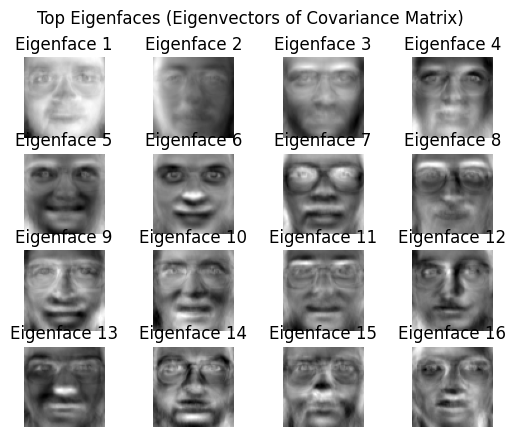

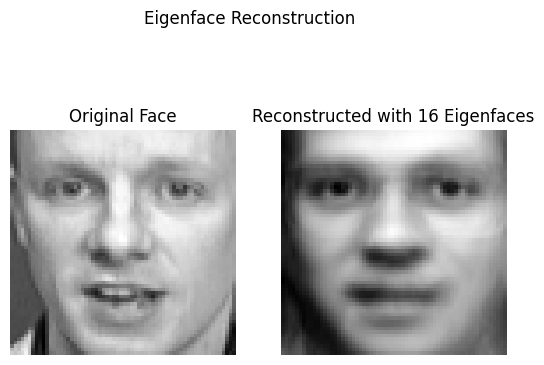

In [ ]:
¸¸# Visual demo of Eigenfaces using real data (Olivetti Faces dataset)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

# Load real face dataset
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data          # shape: (400, 4096)
images = faces.images   # shape: (400, 64, 64)

# Step 1: Fit PCA
k = 16  # number of eigenfaces
pca = PCA(n_components=k, whiten=False, random_state=42)
X_pca = pca.fit_transform(X)

# Step 2: Extract eigenfaces (principal components)
eigenfaces = pca.components_.reshape((k, 64, 64))

# ---- VISUALIZATION ----

# 1. Show some original faces
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"Original {i}")
    plt.axis("off")
plt.suptitle("Original Face Images")
plt.show()

# 2. Show eigenfaces
plt.figure()
for i in range(k):
    plt.subplot(4, 4, i + 1)
    plt.imshow(eigenfaces[i], cmap="gray")
    plt.title(f"Eigenface {i+1}")
    plt.axis("off")
plt.suptitle("Top Eigenfaces (Eigenvectors of Covariance Matrix)")
plt.show()

# 3. Reconstruction using eigenfaces
idx = 0  # pick one face
X_recon = pca.inverse_transform(X_pca[idx])

plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(images[idx], cmap="gray")
plt.title("Original Face")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_recon.reshape(64, 64), cmap="gray")
plt.title(f"Reconstructed with {k} Eigenfaces")
plt.axis("off")

plt.suptitle("Eigenface Reconstruction")
plt.show()


In [ ]:
¸